# Statistische Funktionen (Deskriptive Statistik)
Pandas bietet eine ganz Reihe an Funktionen für die deskriptive Statistik. Mittelwert, Modus, Median, Varianz, Standardabweichung

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Körpergrößen in inch, Gewicht in pounds
df = pd.read_csv("../data/heights.csv")

df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


## Describe
Mit der Funktion describe lassen sich die wichtigsten statistischen Werte eines Dataframes abbilden.

Der Output von df.describe() liefert eine statistische Übersicht numerischer Spalten eines DataFrames, einschließlich Kennzahlen wie Anzahl, Mittelwert, Standardabweichung, Minimum, Maximum sowie Quartile.

**Quartile** sind statistische Kennwerte, die ein geordnetes Datenset in vier gleich große Teile (25%-Schritte) unterteilen und dabei die Verteilung der Daten beschreiben. Sie helfen, Streuung und Schwerpunkte der Daten zu analysieren.

Die Quartile sind:

1. **1. Quartil (Q1)**: Der Wert, unterhalb dessen 25% der Daten liegen (auch **unteres Quartil** genannt).
2. **2. Quartil (Q2)**: Der Wert, unterhalb dessen 50% der Daten liegen (das ist der **Median**).
3. **3. Quartil (Q3)**: Der Wert, unterhalb dessen 75% der Daten liegen (auch **oberes Quartil** genannt).


In [2]:
# Describe
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


## Skalen
Die Kenntnis der **Skalen** ist in Data Science und im Machine Learning entscheidend, weil sie festlegt, **welche statistischen Kennzahlen** (z. B. Mittelwert, Median, Standardabweichung) und **welche Transformationen** (z. B. Standardisierung oder Min-Max-Skalierung) sinnvoll sind.

Viele Verfahren setzen bestimmte Skalentypen implizit voraus, etwa Mittelwerte, Abstände oder Normierungen.
Wer die Skala eines Merkmals falsch behandelt, erzeugt formal korrekte, aber inhaltlich falsche Modelle.


### Nominalskala

Merkmalsausprägungen lassen sich nicht ordnen, z. B. Städtenamen oder Kategorien.
Es kann nur der **Modus** bestimmt werden, also die am häufigsten vorkommende Ausprägung.

### Ordinalskala

Merkmalsausprägungen lassen sich ordnen, die Abstände zwischen den Ausprägungen sind jedoch nicht sinnvoll interpretierbar, z. B. Schulnoten.
Eine 1 ist nicht doppelt so gut wie eine 2 und der Abstand zwischen 4 und 5 ist nicht notwendigerweise gleich dem Abstand zwischen 2 und 3. Es können der **Modus** und der **Median** bestimmt werden.


### Intervall-Skala

Ausprägungen lassen sich ordnen und die Abstände zwischen den Ausprägungen sind sinnvoll interpretierbar (z. B. Temperatur in °C). Der Abstand zwischen 21 °C und 22 °C ist gleich groß wie der Abstand zwischen 34 °C und 35 °C.
Ein natürlicher Nullpunkt fehlt.
Es lassen sich **Modus, Median und Mittelwert** berechnen.

### Verhältnisskala

Die Verhältnisskala ist intervallskaliert und besitzt zusätzlich einen **natürlichen Nullpunkt**. Dadurch sind auch **Verhältnisaussagen** sinnvoll (z. B. Wassertiefe: 120 cm ist doppelt so tief wie 60 cm).
Es lassen sich **Modus, Median und Mittelwert** berechnen.

Nur bei der **Verhältnisskala** sind Aussagen wie
„doppelt so viel“, „halb so groß“ sinnvoll.


## Mittelwert einer Series (Spalte oder Zeile)

Für **quantitative Merkmale** ist der Mittelwert sinnvoll definiert. Liegt das Merkmal auf einer **Verhältnisskala** (mit natürlichem Nullpunkt), ist der berechnete Mittelwert auch inhaltlich direkt interpretierbar.
Auch für quantitative Merkmale auf einer **Intervallskala** kann ein Mittelwert berechnet werden, allerdings ohne Verhältnisinterpretation.
Für Merkmale auf der **Nominal- bzw. Ordinalskala** (z. B. Kategorien wie *rot, grün, blau* oder Schulnoten) ist ein Mittelwert hingegen **nicht sinnvoll definiert**.


Mittelwert der Spalte Height

In [3]:
# Mean einer Spalte
df.Height.mean()

np.float64(66.36755975482124)

## Median

Für **quantitative Merkmale** sowie für Merkmale auf der **Ordinalskala** ist der Median sinnvoll definiert. Der Median ist das **0,5-Quantil** (50-%-Quantil) und teilt die geordneten (sortierten) Daten so, dass 50 % der Beobachtungen kleiner oder gleich und 50 % größer oder gleich sind.

Für Merkmale auf der **Nominalskala** ist der Median hingegen **nicht definiert**, da keine natürliche Ordnung der Ausprägungen existiert.

In [4]:
# Median einer Spalte
df.Weight.median()

np.float64(161.21292769948298)

## Varianz (Streumaß)

Die Varianz drückt die Streuung um den Mittelwert aus. Je höher die Varianz, desto höher die Streung (bei gleich bleibendem Mittelwert). Die Varianz ist allerdings ein quadrierter Wert, deshalb können wir ihn nicht interpretieren. Dafür eignet sich die Standardabweichung.

Berechnung der Varianz: von jedem Wert die Differenzt mit dem Mittelwert berechnen, dann die Differenz quadrieren, dann alles zusammenzählen und am Ende durch die Anzahl der Beobachtungswerte teilen.

$var(x) = \frac{1}{n} \sum_{i=1}^n (x_i - \overline{x})^2$

In [5]:
# Vergleich von Berechnung der Varianz VS der Methode variance
df.Height.var()

np.float64(14.803472640140777)

In [6]:
# Varianz des Gewichts
df.Weight.var()

np.float64(1030.9518554353892)

## Standardabweichung

Die Standardabweichung ist die Wurzel der Varianz; im Gegensatz zur Varianz liegt sie wieder in derselben Einheit wie die Daten und ist damit direkt interpretierbar.

Sie beschreibt die typische Streuung der Beobachtungen um den Mittelwert, also wie weit ein einzelner Wert im Mittel vom Erwartungswert entfernt liegt.

Eine kleine Standardabweichung bedeutet, dass die Daten eng um den Mittelwert konzentriert sind; eine große Standardabweichung bedeutet hohe Heterogenität bzw. starke Streuung.

Wenn man von einer oder zwei Standardabweichungen spricht, meint man den Abstand eines Wertes vom Mittelwert in Einheiten der Standardabweichung; bei (annähernd) normalverteilten Daten liegen etwa 68 % der Beobachtungen innerhalb von ±1 σ und etwa 95 % innerhalb von ±2 σ um den Mittelwert.

$ \sigma = \sqrt{var(x)}$

std:  3.8475281207732293
.hist(): 
 [[<Axes: title={'center': 'Height'}> <Axes: title={'center': 'Weight'}>]]


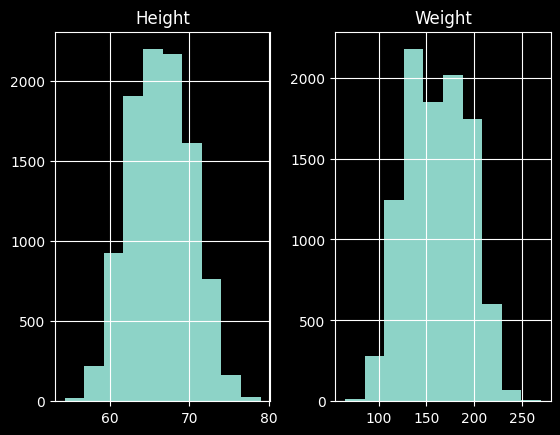

In [7]:
# Berechnung der Standarabweichung als Wurzel der Varianz VS. Methode std
print("std: ", df.Height.std())
print(".hist(): \n", df.hist())

## Modus

der Modus gibt die Merkmalsausprägung an, die am häufigsten vorkam. Er eignet sich vor allem zur **Beschreibung von qualitativen Daten**, die auf einer **Nominalskala gemessen** werden. Zum Beispiel die Zugehörigkeit zu einer Berufsgruppe.

In [8]:
# Modus Methode
print("Gender: \n", df.Gender.mode())
print("Height: \n", df.Height.mode())

Gender: 
 0    Female
1      Male
Name: Gender, dtype: object
Height: 
 0       54.263133
1       54.616858
2       54.873728
3       55.148557
4       55.336492
          ...    
9995    78.095867
9996    78.462053
9997    78.528210
9998    78.621374
9999    78.998742
Name: Height, Length: 10000, dtype: float64


## Min und Max
die Funktionen `min` und `max` lassen sich auf Spalten sowie auf ganze Dataframes anwenden.

In [9]:
# Min und Max auf Spalten angewendet
print("sin .algo: \n", df.max())
print()
print("con .Gender: \n", df.Gender.max())

sin .algo: 
 Gender          Male
Height     78.998742
Weight    269.989699
dtype: object

con .Gender: 
 Male


## MAD: Mittlere absolute Abweichung
Neben Varianz und Standardabweichung gibt es noch ein drittes Maß, welches Streuung charakterisiert, die **mittlere absolute Abweichung***. Sie entspricht der summierten absoluten Differenz der Beobachtungswerte zum Mittelwert. Negative Werte werden also positiv, damit sich in der Summe keine 0 ergibt.

$MAD = \frac{1}{n} \sum_{i=1}^n |x_i - \overline{x}|$

In [10]:
# Aufgabe: berechne die MAD von Weight ohne Zuhilfenahme der Pandas-Funktion mad

## Aufgabe: BMI
a) Füge eine neue Spalte BMI hinzu. 

`BMI-Formel = Körpergewicht (in kg) geteilt durch (Körpergröße (in m) zum Quadrat).`

Beachte, dass die Spalte Weight in Pounds angegeben ist und die Spalte Height in inch.    
- Für die Berechnung benötigen wir kg und m.

* 1 Pound = 0.45 kg
* 1 inch = 2,54 cm

Es muss also für die Spalten `Height` und `Weight` eine Umrechnung stattfinden. 

b) Plotte Histrogramme für für die Spalten `Height` und `Weight`. Nutze dazu df.hist()

NO_changed df: 
   Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801
changed df: 
   Gender     Height      Weight   Weight_kg  Height_m        BMI
0   Male  73.847017  241.893563  109.720985  1.875714  31.185761
1   Male  68.781904  162.310473   73.622732  1.747060  24.121044
2   Male  74.110105  212.740856   96.497550  1.882397  27.232906
3   Male  71.730978  220.042470   99.809504  1.821967  30.067059
4   Male  69.881796  206.349801   93.598619  1.774998  29.708033


array([[<Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>]], dtype=object)

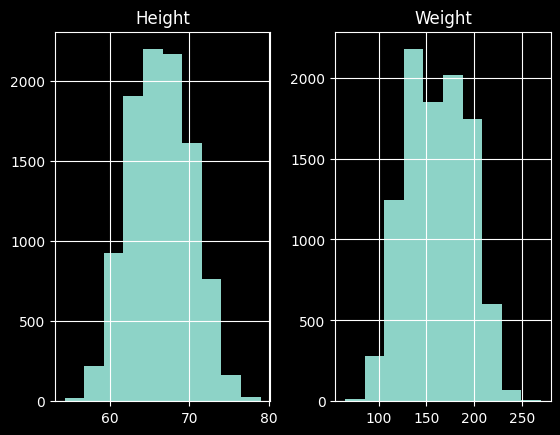

In [11]:
import pandas as pd

PD_TO_KG = 0.453592        # usa 0.453592 si quieres más exactitud
IN_TO_M  = 0.0254

# df["new"] = [1....10000]
# Happy Coding (10 Minuten Zeit)
df = pd.read_csv("../data/heights.csv")


print("NO_changed df: \n", df.head())

# modificar weight a Kg & height a Meters
df["Weight_kg"] = df["Weight"] * PD_TO_KG
df["Height_m"]  = df["Height"] * IN_TO_M

# create neu Column BMI
df["BMI"] = (df["Weight_kg"]) / (df["Height_m"] ** 2)
print("changed df: \n", df.head())


df[["Height", "Weight"]].hist()

## Plot von zwei Features des Datensatzes: Height und Weight

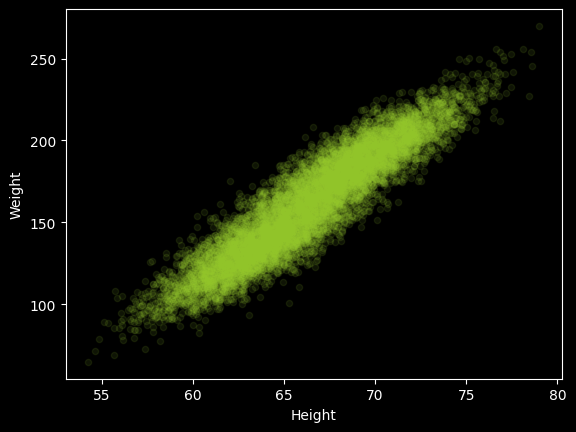

In [12]:
# Scatterplot von Körpergröße und Gewicht
df.plot(kind="scatter", x="Height", y="Weight", alpha=0.1, color="yellowgreen")
plt.show()

<Axes: title={'center': 'Height'}, xlabel='Gender'>

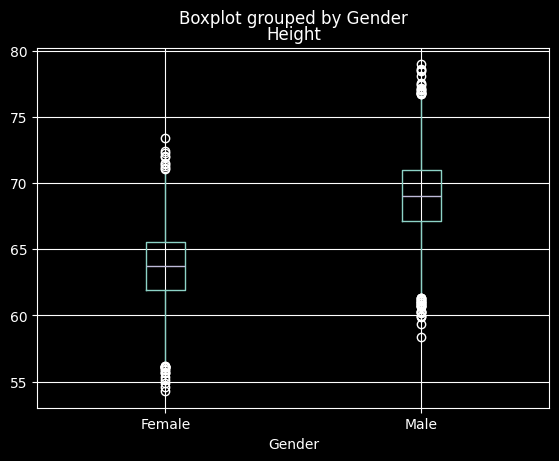

In [13]:
# Boxplot Lörpergröße
df.boxplot(column='Height', by='Gender')

<Axes: title={'center': 'Weight'}, xlabel='Gender'>

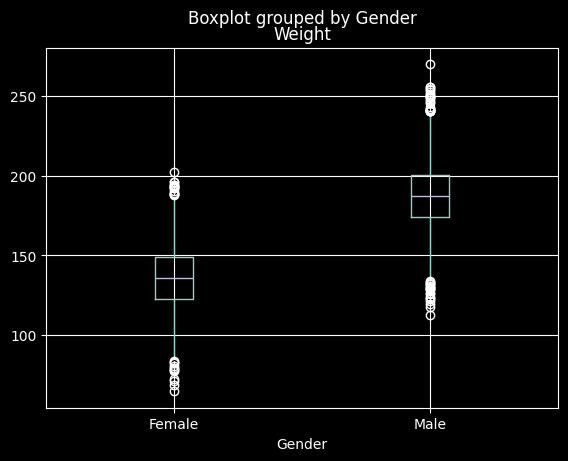

In [14]:
# Boxplot Gewicht
df.boxplot(column='Weight', by='Gender')


## Histogramme der Eigenschaften

array([[<Axes: title={'center': 'Height'}>,
        <Axes: title={'center': 'Weight'}>],
       [<Axes: title={'center': 'Weight_kg'}>,
        <Axes: title={'center': 'Height_m'}>],
       [<Axes: title={'center': 'BMI'}>, <Axes: >]], dtype=object)

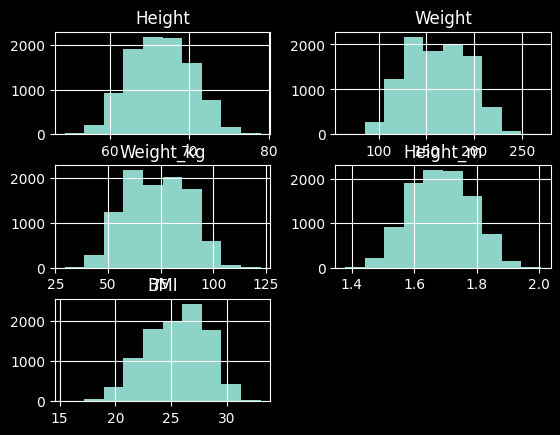

In [15]:
# Histogramm des Dataframes
df.hist()

## Kovarianz zwischen zwei Features

Sie gibt die Richtung des Zusammenhangs zwischen zwei quantitativen Merkmalen an. Die Summe der Produkte der Differenzen von x - Mittelwert und y - Mittelwert durch die Summe aller Datenpunkte. Nimmt die Kovarianz einen postiven Wert an, korrelieren die beiden Werte positiv. Ansonsten halt negativ. Wenn sie 0 ist, korrelieren die Werte überhaupt nicht.

**Formel der Kovarianz:**

$c_{XY} = \frac{1}{n} \sum_{i=1}^n (x_i - \overline{x}) (y_i - \overline{y})$    
$\overline{y}$ = Mittelwert der y-Werte     
$\overline{x}$ = Mittelwert der x-Werte  

### Pandas cov
Die Pandas-Methode cov() errechnet die Kovarianz-Matrix von n Eingabe-Features, also Spalten. Aus dieser lassen sich die Varianzen der einzelnen Features sowie die Kovarianzen der verglichenen Features ausrechnen.

Im Beispiel ist die Varianz für das Gewicht 257.73, die Varianz der Höhe 0.009511. Die Kovarianz beträgt 1.45.
Alle Werte NACH Umrechnung in Meter und Kilogramm.

In [16]:
# cov
df[["Weight", "Height"]].cov()

,Weight,Height
Weight,1030.951855,114.242656
Height,114.242656,14.803473


## Korrelationskoeffizient
Der Korrelationskoeffizient zeigt die Stärke des Zusammenhangs zwischen zwei quantitativen Merkmalen.
Wir teilen die Kovarianz durch das Produkt von Standardabweichung von X und Standardabweichung von Y.

$r_{XY} = \frac{c_{XY}}{s_X \cdot s_Y}$

### Aussage
Als Konsequenz ergibt sich, dass der Korrelationskoeffizient nur Werte zwischen –1 und +1 annehmen kann

Starke negative Korrelation wenn $ -1 ≤r_{XY} < -0,6 $    
Schwache negative Korrelation wenn $ -0,6 ≤ r_{XY} < 0 $      
keine Korrelation: $r_{XY} = 0 $     
Schwache positive Korrelation wenn $ 0 < r_{XY} ≤ 0,6 $       
Starke positive Korrelation wenn $ 0,6 < r_{XY} ≤ 1 $      

Über den Parameter `method` lässt sich die Methode angeben, Standard ist `Pearson`. 

siehe Doku:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

In [17]:
# Korrelationskoeffizient
df[["Weight", "Height"]].corr()


,Weight,Height
Weight,1.000000,0.924756
Height,0.924756,1.000000


## Aufgabe: Aktien

wir sollen die Kurse der beiden Gringotts Aktien "Wizards Brooms" (X) und "Witches and Ditches Inc." (Y) vergleichen.
Korrelieren die beiden Kurse?


### Aufgabe
* Erstelle einen neuen DataFrame
* Bestimme Mittelwert und Median der beiden Aktienkurse. 
* Bestimme Varianz und Standardabweichung der beiden Aktienkurse. 
* Fertige einen Scatterplot der beiden Features an.    
* Bestimme den Korrelationskoeffizienten der beiden Aktienkurse.    


In [18]:
brooms = [27.9, 28.2, 27.5, 28.3, 28.2, 28.7, 27.9, 27.3, 29.1, 29.6, 29.5, 29.8]
witches_inc = [43, 46.1, 43.4, 43.8, 47.3, 47.8, 43.2, 45.2, 47.2, 45.7, 48.5, 50.6]

df 1 
     brooms  witches_inc
0     27.9         43.0
1     28.2         46.1
2     27.5         43.4
3     28.3         43.8
4     28.2         47.3
5     28.7         47.8
6     27.9         43.2
7     27.3         45.2
8     29.1         47.2
9     29.6         45.7
10    29.5         48.5
11    29.8         50.6

 df 2 
     brooms  witches_inc
0     27.9         43.0
1     28.2         46.1
2     27.5         43.4
3     28.3         43.8
4     28.2         47.3
5     28.7         47.8
6     27.9         43.2
7     27.3         45.2
8     29.1         47.2
9     29.6         45.7
10    29.5         48.5
11    29.8         50.6
 ********  ********  ********  ********  ********  ********  ********  ********  ********  ******** 
Correlation: 0.7408317922360476
 ********  ********  ********  ********  ********  ********  ********  ********  ********  ******** 


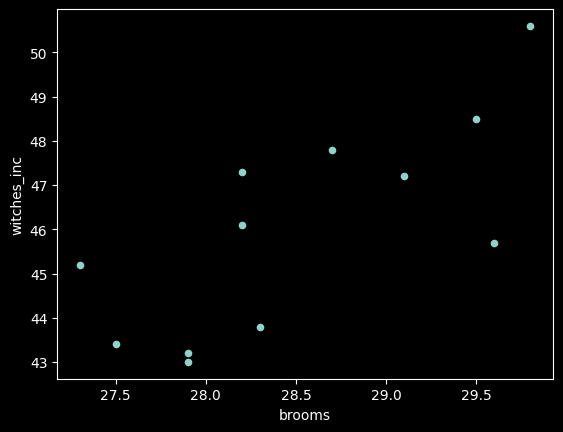

In [27]:
# Erstelle DataFrame mit zwei Spalten brooms und witches_inc
df = pd.DataFrame({"brooms": brooms, "witches_inc": witches_inc})

# Bestimme Mittelwert und Median der beiden Aktienkurse.

# <---- codigo
"""print("Mean: \n", df.mean())
print(" ******** " * 10)
print("Median: \n", df.median())
print(" ******** " * 10)"""
df.agg(["mean", "median"]) # <---- opcion "PRO"
print("df 1 \n", df)

# Bestimme Varianz und Standardabweichung der beiden Aktienkurse.
# <---- codigo
"""df.brooms.var()
df.witches_inc.var()
df.brooms.std()
df.witches_inc.std()"""
df.agg(["var", "std"]) # <---- opcion "PRO"
print("\n df 2 \n", df)
print(" ******** " * 10)

# Fertige einen Scatterplot der beiden Features an. df.plot(kind="scatter", x="brooms", y="witches_inc")
df.plot(kind="scatter", x="brooms", y="witches_inc")

# Bestimme den Korrelationskoeffizienten der beiden Aktienkurse (siehe cov() und corr())
print("Correlation:", df["brooms"].corr(df["witches_inc"]))
print(" ******** " * 10)
